In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.1 MB/s eta 0:00:00


In [ ]:
import os
import glob
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from scipy.signal import spectrogram

In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"pooraniayswariyaps","key":"8fa92518aa934ee81e2033d115dd20a2"}'}

In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle.json configured successfully!")

Kaggle.json configured successfully!


In [ ]:
!pip install kaggle


In [ ]:
!kaggle datasets download -d brjapon/cwru-bearing-datasets

Dataset URL: https://www.kaggle.com/datasets/brjapon/cwru-bearing-datasets
License(s): CC-BY-SA-4.0
100% 40.4M/40.4M [00:00<00:00, 209MB/s]



In [ ]:
import zipfile

zip_path = "cwru-bearing-datasets.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("CWRU_Dataset")

print("Dataset extracted successfully into CWRU_Dataset folder!")


Dataset extracted successfully into CWRU_Dataset folder!


In [ ]:
DATA_PATH = "CWRU_Dataset/raw/*.mat"
mat_files = glob.glob(DATA_PATH)

print("Total .mat files:", len(mat_files))

Total .mat files: 10


In [ ]:
def extract_signal_from_mat(file_path):
    mat_data = sio.loadmat(file_path)
    for key in mat_data.keys():
        if "DE_time" in key:
            return mat_data[key].flatten()
    raise ValueError("No DE_time found")

In [ ]:
def get_label_from_filename(file_path):
    filename = os.path.basename(file_path)

    if "Normal" in filename:
        return "Normal"
    elif filename.startswith("IR"):
        return "IR"
    elif filename.startswith("OR"):
        return "OR"
    elif filename.startswith("B"):
        return "B"
    else:
        return "Unknown"

In [ ]:
def segment_signal(signal, segment_size=2048):
    segments = []
    step = segment_size // 2

    for i in range(0, len(signal) - segment_size, step):
        seg = signal[i:i+segment_size]

        # Normalize each segment
        seg = (seg - np.mean(seg)) / (np.std(seg) + 1e-10)

        segments.append(seg)

    return np.array(segments)

In [ ]:
IMG_SIZE = 128

def signal_to_spectrogram(segment,
                          fs=12000,
                          nperseg=256,
                          noverlap=128):

    f, t, Sxx = spectrogram(
        segment,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap
    )

    Sxx = np.log(Sxx + 1e-10)

    Sxx = (Sxx - Sxx.min()) / (
        Sxx.max() - Sxx.min() + 1e-10
    )

    Sxx = tf.image.resize(
        Sxx[..., np.newaxis],
        (IMG_SIZE, IMG_SIZE)
    ).numpy()

    return Sxx

In [ ]:
X = []
y = []

for file in mat_files:

    signal = extract_signal_from_mat(file)

    label = get_label_from_filename(file)

    if label == "Unknown":
        continue

    segments = segment_signal(signal)

    for seg in segments:

        img = signal_to_spectrogram(seg)

        X.append(img)

        y.append(label)


X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)

X shape: (4735, 128, 128, 1)


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)

Classes: ['B' 'IR' 'Normal' 'OR']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (3788, 128, 128, 1)
Test : (947, 128, 128, 1)


In [ ]:
if len(X_train.shape) == 4:
    X_train = np.repeat(X_train, 3, axis=-1)
    X_test = np.repeat(X_test, 3, axis=-1)

print(X_train.shape)

(3788, 128, 128, 3)


In [ ]:
if len(X_train.shape) == 4 and X_train.shape[-1] == 3:
    X_train_ae = np.mean(X_train, axis=-1, keepdims=True)
    X_test_ae = np.mean(X_test, axis=-1, keepdims=True)
else:
    X_train_ae = X_train[..., np.newaxis]
    X_test_ae = X_test[..., np.newaxis]


AE

In [ ]:
import keras_tuner as kt

def build_ae(hp):

    latent_dim = hp.Choice('latent_dim', [32, 64, 128])

    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    x = Conv2D(
        filters=hp.Choice('filters1', [32,64]),
        kernel_size=3,
        strides=2,
        padding='same',
        activation='relu'
    )(inputs)

    x = BatchNormalization()(x)

    x = Conv2D(
        filters=hp.Choice('filters2', [64,128]),
        kernel_size=3,
        strides=2,
        padding='same',
        activation='relu'
    )(x)

    x = Flatten()(x)
    latent = Dense(latent_dim)(x)

    # Decoder
    x = Dense(32*32*64, activation='relu')(latent)
    x = Reshape((32,32,64))(x)

    x = Conv2DTranspose(64,3,strides=2,padding='same',activation='relu')(x)
    x = BatchNormalization()(x)

    outputs = Conv2DTranspose(1,3,strides=2,padding='same',activation='sigmoid')(x)

    model = Model(inputs, outputs)

    lr = hp.Choice('lr', [1e-3,1e-4])

    model.compile(optimizer=Adam(lr), loss='mse')

    return model

In [ ]:
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, Flatten, Reshape
from tensorflow.keras.models import Model

ae_tuner = kt.RandomSearch(
    build_ae,
    objective='val_loss',
    max_trials=5,
    directory='ae_tuning',
    project_name='AE'
)

ae_tuner.search(
    X_train_ae, X_train_ae,
    validation_data=(X_test_ae, X_test_ae),
    epochs=10
)

best_ae = ae_tuner.get_best_models(1)[0]

Trial 5 Complete [00h 19m 17s]
val_loss: 0.002544873161241412

Best val_loss So Far: 0.0025220175739377737
Total elapsed time: 02h 06m 30s


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
best_ae.compile(
    optimizer=Adam(1e-5),   # lower LR
    loss='mse'
)

history_ae = best_ae.fit(
    X_train_ae, X_train_ae,
    epochs=20,
    validation_data=(X_test_ae, X_test_ae)
)

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 211s 2s/step - loss: 0.0024 - val_loss: 0.0023
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - loss: 0.0023 - val_loss: 0.0023
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 194s 2s/step - loss: 0.0023 - val_loss: 0.0023
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - loss: 0.0023 - val_loss: 0.0023
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - loss: 0.0023 - val_loss: 0.0023
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 203s 2s/step - loss: 0.0023 - val_loss: 0.0023
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - loss: 0.0023 - val_loss: 0.0023
Epoch 8/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - loss: 0.0023 - val_loss: 0.0023
Epoch 9/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - loss: 0.0023 - val_loss: 0.0022
Epoch 10/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - loss: 0.0023 - val_loss: 0.0022
Epoch 11/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - loss: 0.0023 - val_loss: 0.0022
Epoch 12/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
LATENT_DIM = 64   # try: 64, 100
LR = 1e-4         # try: 1e-3, 1e-4
BATCH_SIZE = 32   # try: 32, 64
EPOCHS = 20

In [ ]:
real = np.ones((BATCH_SIZE,1)) * 0.9
fake = np.zeros((BATCH_SIZE,1))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Reshape, Conv2DTranspose, BatchNormalization

def build_generator():
    model = Sequential()

    model.add(Input(shape=(LATENT_DIM,)))

    model.add(Dense(8*8*128))
    model.add(Reshape((8,8,128)))

    # 8 → 16
    model.add(Conv2DTranspose(128, 4, strides=2, padding='same', activation='relu'))
    model.add(BatchNormalization())

    # 16 → 32
    model.add(Conv2DTranspose(64, 4, strides=2, padding='same', activation='relu'))
    model.add(BatchNormalization())

    # 32 → 64
    model.add(Conv2DTranspose(32, 4, strides=2, padding='same', activation='relu'))
    model.add(BatchNormalization())

    # 64 → 128 FIXED
    model.add(Conv2DTranspose(1, 4, strides=2, padding='same', activation='sigmoid'))

    return model

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, Flatten, LeakyReLU

def build_discriminator():
    model = Sequential()

    model.add(Input(shape=(IMG_SIZE, IMG_SIZE, 1)))

    model.add(Conv2D(64, 4, strides=2, padding='same'))
    model.add(LeakyReLU(0.2))

    model.add(Conv2D(128, 4, strides=2, padding='same'))
    model.add(LeakyReLU(0.2))

    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))

    return model

In [ ]:
generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

discriminator.trainable = False

gan_input = Input(shape=(LATENT_DIM,))
fake_img = generator(gan_input)
gan_output = discriminator(fake_img)

gan = Model(gan_input, gan_output)

gan.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy'
)

In [ ]:
generator.summary()
discriminator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 8192)           │       532,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 16, 16, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 32, 32, 64)     │       131,136 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_4              │ (None, 64, 64, 32)     │        32,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_5              │ (None, 128, 128, 1)    │           513 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 960,097 (3.66 MB)

 Trainable params: 959,649 (3.66 MB)

 Non-trainable params: 448 (1.75 KB)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │       131,073 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 263,361 (1.00 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 263,361 (1.00 MB)

In [ ]:
for epoch in range(EPOCHS):

    idx = np.random.randint(0, X_train_ae.shape[0], BATCH_SIZE)
    real_imgs = X_train_ae[idx]

    # Noise injection (VERY IMPORTANT)
    real_imgs = real_imgs + 0.05 * np.random.normal(size=real_imgs.shape)

    noise = np.random.normal(0,1,(BATCH_SIZE, LATENT_DIM))
    fake_imgs = generator.predict(noise)

    # Train discriminator MORE (fine tuning)
    for _ in range(2):
        d_loss_real = discriminator.train_on_batch(real_imgs, real)
        d_loss_fake = discriminator.train_on_batch(fake_imgs, fake)

    noise = np.random.normal(0,1,(BATCH_SIZE, LATENT_DIM))
    g_loss = gan.train_on_batch(noise, real)

    if epoch % 10 == 0:
        print(f"{epoch} [D loss: {d_loss_real}] [G loss: {g_loss}]")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


0 [D loss: [array(0.687644, dtype=float32), array(0., dtype=float32)]] [G loss: 0.660546064376831]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
10 [D loss: [array(0.698481, dtype=float32), array(0., dtype=float32)]] [G loss: 0.65473872423172]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step


In [ ]:
discriminator.compile(optimizer=Adam(1e-5), loss='binary_crossentropy')
gan.compile(optimizer=Adam(1e-5), loss='binary_crossentropy')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step


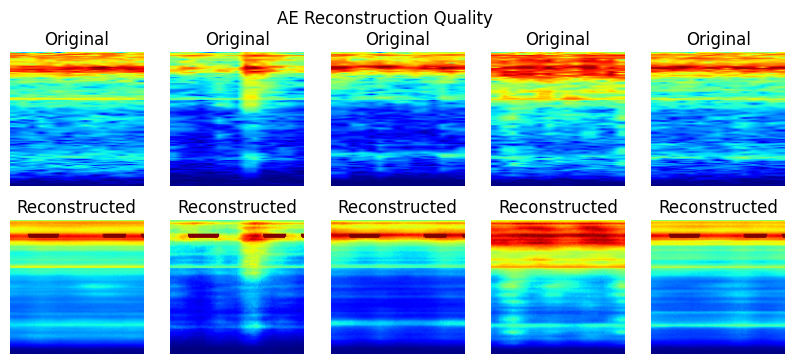

In [ ]:
n = 5
decoded_imgs = best_ae.predict(X_test_ae[:n])

plt.figure(figsize=(10,4))

for i in range(n):
    # Original
    plt.subplot(2, n, i+1)
    plt.imshow(X_test_ae[i].squeeze(), cmap='jet')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, n, i+n+1)
    plt.imshow(decoded_imgs[i].squeeze(), cmap='jet')
    plt.title("Reconstructed")
    plt.axis('off')

plt.suptitle("AE Reconstruction Quality")
plt.show()

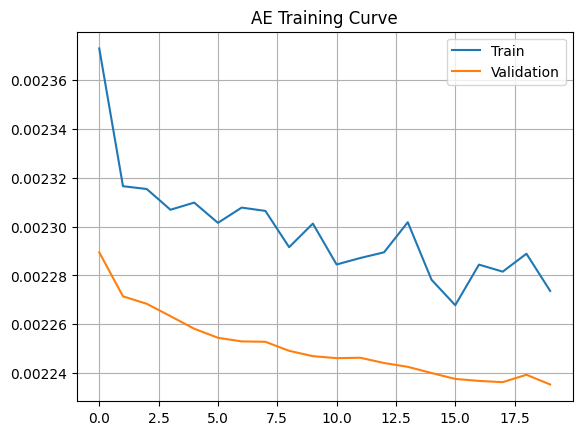

In [ ]:
plt.plot(history_ae.history['loss'], label='Train')
plt.plot(history_ae.history['val_loss'], label='Validation')
plt.title("AE Training Curve")
plt.legend()
plt.grid()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step


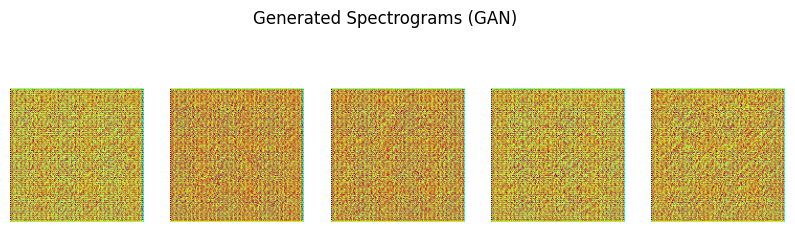

In [ ]:
noise = np.random.normal(0,1,(5, LATENT_DIM))
gen_imgs = generator.predict(noise)

plt.figure(figsize=(10,3))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(gen_imgs[i].squeeze(), cmap='jet')
    plt.axis('off')

plt.suptitle("Generated Spectrograms (GAN)")
plt.show()

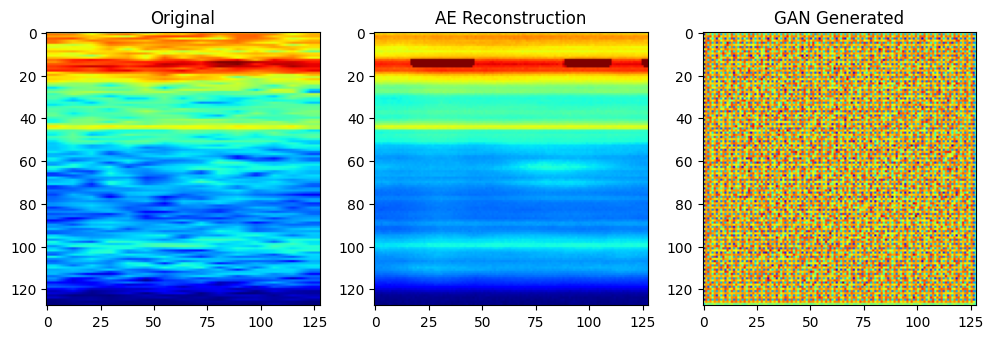

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_test_ae[0].squeeze(), cmap='jet')
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(decoded_imgs[0].squeeze(), cmap='jet')
plt.title("AE Reconstruction")

plt.subplot(1,3,3)
plt.imshow(gen_imgs[0].squeeze(), cmap='jet')
plt.title("GAN Generated")

plt.show()

In [ ]:
recon = best_ae.predict(X_test_ae)

mse = np.mean((X_test_ae - recon)**2)

print("Reconstruction Error (MSE):", mse)

30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 285ms/step
Reconstruction Error (MSE): 0.0022352901


In [37]:
best_ae.save("ae_model1.h5")
generator.save("gan_generator1.h5")

In [ ]:
best_ae.save("ae_model.keras")
generator.save("gan_generator.keras")